#Masuk ke Direktori Proyek

In [1]:
!git clone https://github.com/ADAzhari/Proyek_SoftCom
%cd Proyek_SoftCom

!mkdir -p models data/raw data/processed


Cloning into 'Proyek_SoftCom'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 27 (delta 7), reused 20 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 8.55 KiB | 2.14 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/Proyek_SoftCom


#Install Dependensi

In [3]:
!pip install opencv-python scikit-learn numpy pandas matplotlib seaborn tqdm mediapipe -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 115.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 14.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.9 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.


#Mount Google Drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
MODEL_SAVE_PATH = '/content/drive/MyDrive/Proyek_SoftCom/models'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
print(f"Model akan disimpan ke: {MODEL_SAVE_PATH}")

Mounted at /content/drive
Model akan disimpan ke: /content/drive/MyDrive/Proyek_SoftCom/models


#Download Dataset (Sementara Pakai dari Kaggle)


In [4]:
import os

os.environ['KAGGLE_TOKEN'] = 'KGAT_9890be980db76d9510d3ba8d09ec50b2'

!mkdir -p ~/.kaggle
!echo "{\"username\":\"adazhari34\",\"key\":\"$KAGGLE_TOKEN\"}" > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ismailnasri20/driver-drowsiness-dataset-ddd \
    --unzip -p /content/Proyek_SoftCom/data/raw

!ls ./content/Proyek_SoftCom/data/raw

Dataset URL: https://www.kaggle.com/datasets/ismailnasri20/driver-drowsiness-dataset-ddd
License(s): unknown
100% 2.58G/2.58G [00:29<00:00, 94.1MB/s]

ls: cannot access './content/Proyek_SoftCom/data/raw': No such file or directory


In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path('/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)')
for item in sorted(data_dir.rglob('*'))[:20]:
    print(item)

/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy/A0001.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy/A0002.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy/A0003.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy/A0004.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy/A0005.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy/A0006.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy/A0007.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy/A0008.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy/A0009.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy/A0010.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy/A0011.png
/content/Proyek_SoftCom/da

In [6]:
!find /content/Proyek_SoftCom/data/raw -type d
!find /content/Proyek_SoftCom/data/raw -name "*.jpg" | head -10
!find /content/Proyek_SoftCom/data/raw -name "*.png" | head -10

/content/Proyek_SoftCom/data/raw
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Non Drowsy
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Drowsy
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Non Drowsy/a0002.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Non Drowsy/a0003.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Non Drowsy/a0004.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Non Drowsy/a0005.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Non Drowsy/a0006.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Non Drowsy/a0007.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Non Drowsy/a0009.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/Non Drowsy/a0010.png
/content/Proyek_SoftCom/data/raw/Driver Drowsiness Dataset (DDD)/N

In [7]:
# Menghitung jumlah gambar per kelas
classes = [d for d in data_dir.iterdir() if d.is_dir()]
for cls in classes:
    n = len(list(cls.glob('*.jpg')) + list(cls.glob('*.png')))
    print(f"{cls.name}: {n} gambar")

Non Drowsy: 19445 gambar
Drowsy: 22348 gambar


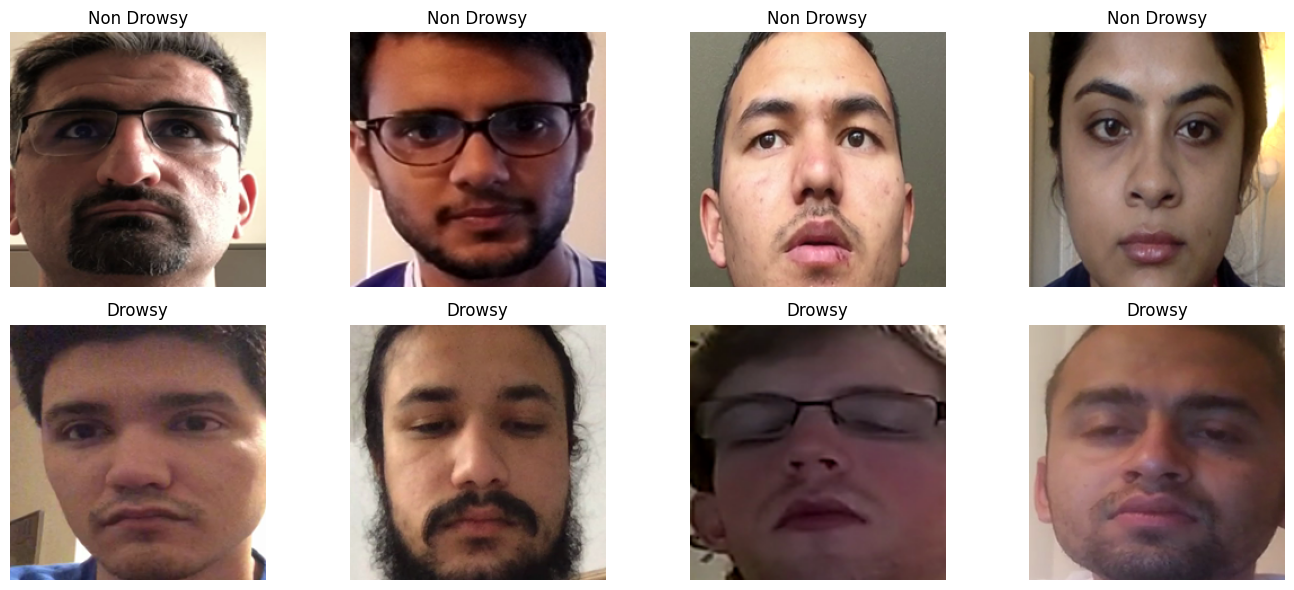

In [8]:

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, cls in enumerate(classes[:2]):
    images = list(cls.glob('*.png'))[:4] or list(cls.glob('*.jpg'))[:4]
    for j, img_path in enumerate(images):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i][j].imshow(img)
        axes[i][j].set_title(cls.name)
        axes[i][j].axis('off')
plt.tight_layout()
plt.show()

#Import Module


In [11]:
import sys
sys.path.append('/content/Proyek_SoftCom')

from feature_engineering.landmark_extractor import LandmarkExtractor
from feature_engineering.au_calculator import compute_au_vector, PERCLOSCalculator
from feature_engineering.head_pose import estimate_head_pose

ImportError: cannot import name 'runtime_version' from 'google.protobuf' (/usr/local/lib/python3.12/dist-packages/google/protobuf/__init__.py)

#Ekstraksi Fitur

In [ ]:
from tqdm import tqdm

extractor  = LandmarkExtractor()
perclos    = PERCLOSCalculator(window_seconds=5, fps=1)

records = []

for cls in classes:
    # label: 0 = normal, 1 = drowsy
    label     = 1 if 'drowsy' in cls.name.lower() else 0
    img_paths = list(cls.glob('*.jpg')) + list(cls.glob('*.png'))

    for img_path in tqdm(img_paths, desc=cls.name):
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        landmarks = extractor.extract(img)
        if landmarks is None:
            continue

        # hitung AU vector
        au = compute_au_vector(landmarks)

        # hitung head pose
        pose = estimate_head_pose(landmarks, img.shape)
        pitch = pose[0] if pose is not None else 0.0

        # update & hitung PERCLOS
        perclos.update(au['EAR'])
        perclos_val = perclos.compute()

        records.append({
            'EAR':       au['EAR'],
            'EAR_asym':  abs(au['EAR_left'] - au['EAR_right']),
            'PERCLOS':   perclos_val,
            'BROW':      au['BROW'],
            'PITCH':     pitch,
            'label':     label   # 0 atau 1
        })

df = pd.DataFrame(records)
print(f"\nTotal sampel: {len(df)}")
print(f"Label distribusi:\n{df['label'].value_counts()}")
df.head()

#Fatigue Score


In [ ]:
def label_to_fatigue_score(label):
    """
    Konversi label binary ke fatigue score kontinu
    Normal (0)  → score 20-50  (ada variasi, tidak semua sama)
    Drowsy (1)  → score 70-95
    """
    if label == 0:
        # normal: distribusi gaussian sekitar 35
        return np.clip(np.random.normal(35, 10), 10, 55)
    else:
        # drowsy: distribusi gaussian sekitar 80
        return np.clip(np.random.normal(80, 10), 65, 100)

np.random.seed(42)
df['fatigue_score'] = df['label'].apply(label_to_fatigue_score)

# visualisasi distribusi score
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df[df['label']==0]['fatigue_score'].hist(bins=20, color='green', alpha=0.7)
df[df['label']==1]['fatigue_score'].hist(bins=20, color='red', alpha=0.7)
plt.legend(['Normal', 'Drowsy'])
plt.title('Distribusi Fatigue Score')
plt.xlabel('Fatigue Score')

plt.subplot(1, 2, 2)
df.boxplot(column='EAR', by='label')
plt.title('EAR per Label')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(df[['EAR','EAR_asym','PERCLOS','BROW','PITCH','fatigue_score']].describe())

#Save Dataset

In [ ]:
processed_path = './data/processed/features.csv'
df.to_csv(processed_path, index=False)
print(f"Dataset tersimpan: {processed_path} ({len(df)} baris)")


!cp ./data/processed/features.csv \
    '/content/drive/MyDrive/Proyek_SoftCom/features.csv'
print("Backup ke Drive ✓")

#Split Menjaddi Train/Test

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

features = ['EAR', 'EAR_asym', 'PERCLOS', 'BROW', 'PITCH']
target   = 'fatigue_score'

X = df[features].values
y = df[target].values

# normalisasi fitur ke range 0-1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=df['label']   # jaga proporsi kelas
)

print(f"Train: {X_train.shape[0]} sampel")
print(f"Test : {X_test.shape[0]} sampel")


#Train ANFIS

In [ ]:
from anfis.anfis_model import ANFIS
from anfis.train import ANFISTrainer
import matplotlib.pyplot as plt

# inisialisasi model
model   = ANFIS(n_mf=3)
trainer = ANFISTrainer(model, lr=0.01)

# training
print("Mulai training ANFIS...")
history = trainer.train(X_train, y_train, epochs=100, verbose=True)

# plot learning curve
plt.figure(figsize=(8, 4))
plt.plot(history)
plt.title('ANFIS Training — RMSE per Epoch')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.grid(True)
plt.tight_layout()
plt.show()

#Evaluasi

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=" * 35)
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}")
print("=" * 35)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot([0, 100], [0, 100], 'r--', label='Ideal')
plt.xlabel('Fatigue Score Aktual')
plt.ylabel('Fatigue Score Prediksi')
plt.title('Prediksi vs Aktual')
plt.legend()
plt.tight_layout()
plt.show()

#Export Model

In [ ]:
import pickle

trainer.save_model('models/anfis_model.pkl')

with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved → models/scaler.pkl")

!cp models/anfis_model.pkl \
    '/content/drive/MyDrive/Proyek_SoftCom/models/anfis_model.pkl'
!cp models/scaler.pkl \
    '/content/drive/MyDrive/Proyek_SoftCom/models/scaler.pkl'
print("Backup ke Drive ✓")